In [1]:
# !pip install scikit-learn==1.0.2 imbalanced-learn==0.8.1
!pip install -U scikit-learn imbalanced-learn


import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import joblib

# Configuration
DATA_DIR = "/kaggle/input/potato-disease-data/PlantVillage - Copy"  # Update with your dataset path
CLASSES = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load and split data
print("Loading image paths and labels...")
image_paths = []
labels = []
for class_idx, class_name in enumerate(CLASSES):
    class_dir = os.path.join(DATA_DIR, class_name)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        image_paths.append(img_path)
        labels.append(class_idx)

# Split dataset: 80% train, 10% validation, 10% test
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"\nDataset sizes:")
print(f"Training: {len(X_train_paths)} images")
print(f"Validation: {len(X_val_paths)} images")
print(f"Test: {len(X_test_paths)} images")

# Initialize feature extractor
print("\nLoading MobileNetV2 for feature extraction...")
feature_extractor = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)

def batch_extract_features(image_paths, batch_size=32):
    """Efficient batch feature extraction with progress bar"""
    features = []
    for i in tqdm(range(0, len(image_paths), batch_size), 
                 desc="Extracting features"):
        batch_paths = image_paths[i:i+batch_size]
        batch_images = []
        for img_path in batch_paths:
            img = image.load_img(img_path, target_size=IMG_SIZE)
            x = image.img_to_array(img)
            x = preprocess_input(x)
            batch_images.append(x)
        
        batch_images = np.array(batch_images)
        batch_features = feature_extractor.predict(batch_images, verbose=0)
        features.extend(batch_features.reshape(len(batch_images), -1))
    return np.array(features)

# Extract features
print("\nProcessing training set...")
X_train_features = batch_extract_features(X_train_paths, BATCH_SIZE)
print("\nProcessing validation set...")
X_val_features = batch_extract_features(X_val_paths, BATCH_SIZE)
print("\nProcessing test set...")
X_test_features = batch_extract_features(X_test_paths, BATCH_SIZE)

# Apply SMOTE oversampling
print("\nBalancing classes with SMOTE...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_features, y_train)

print("\nClass distribution after SMOTE:")
import numpy as np  # make sure this is imported at the top

print(f"early-blight: {np.sum(np.array(y_train_res) == 0)}")
print(f"late-blight: {np.sum(np.array(y_train_res) == 1)}")
print(f"healthy: {np.sum(np.array(y_train_res) == 2)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 101.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.


2025-06-05 09:15:40.827908: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749114941.298072      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749114941.428322      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Loading image paths and labels...

Dataset sizes:
Training: 4322 images
Validation: 540 images
Test: 541 images

Loading MobileNetV2 for feature extraction...


I0000 00:00:1749114967.052980      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1749114967.053733      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Processing training set...


...


Processing validation set...


Extracting features: 100%|██████████| 17/17 [00:09<00:00,  1.78it/s]



Processing test set...


Extracting features: 100%|██████████| 17/17 [00:09<00:00,  1.75it/s]



Balancing classes with SMOTE...

Class distribution after SMOTE:
early-blight: 1842
late-blight: 1842
healthy: 1842


In [2]:
# Train Random Forest with accuracy tracking
print("\nTraining Random Forest...")
# Varying number of trees to observe training & validation accuracy
tree_counts = [50, 100, 150, 200, 250]
train_accuracies = []
val_accuracies = []

print("\nTraining Random Forest with varying number of trees...")

for n_trees in tree_counts:
    rf = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=30,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_res, y_train_res)

    train_acc = rf.score(X_train_res, y_train_res)
    val_acc = rf.score(X_val_features, y_val)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"{n_trees} trees -> Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")



Training Random Forest...

Training Random Forest with varying number of trees...
50 trees -> Train Acc: 0.9996, Val Acc: 0.9204
100 trees -> Train Acc: 0.9998, Val Acc: 0.9148
150 trees -> Train Acc: 0.9998, Val Acc: 0.9315
200 trees -> Train Acc: 0.9998, Val Acc: 0.9278
250 trees -> Train Acc: 0.9998, Val Acc: 0.9315


In [3]:
# Store accuracy metrics
train_accuracies = []
val_accuracies = []
tree_counts = []

In [4]:
# Train in increments for accuracy tracking
n_estimators_increment = 20
n_steps = 200 // n_estimators_increment

for i in tqdm(range(1, n_steps + 1), desc="Training Progress"):
    n_trees = i * n_estimators_increment
    rf.n_estimators = n_trees
    rf.fit(X_train_res, y_train_res)

Training Progress: 100%|██████████| 10/10 [01:00<00:00,  6.08s/it]


In [5]:
    
    # Calculate accuracies
    train_pred = rf.predict(X_train_res)
    val_pred = rf.predict(X_val_features)
    
    train_acc = accuracy_score(y_train_res, train_pred)
    val_acc = accuracy_score(y_val, val_pred)
    
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    tree_counts.append(n_trees)
    
    print(f"Trees: {n_trees:3d} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Trees: 200 | Train Acc: 0.9998 | Val Acc: 0.9278


In [6]:
# Final evaluation on test set
print("\nFinal Evaluation on Test Set:")
y_pred = rf.predict(X_test_features)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES))


Final Evaluation on Test Set:
Test Accuracy: 0.9390

Classification Report:
                       precision    recall  f1-score   support

Potato___Early_blight       0.98      0.95      0.97       231
 Potato___Late_blight       0.92      0.94      0.93       213
     Potato___healthy       0.88      0.90      0.89        97

             accuracy                           0.94       541
            macro avg       0.93      0.93      0.93       541
         weighted avg       0.94      0.94      0.94       541



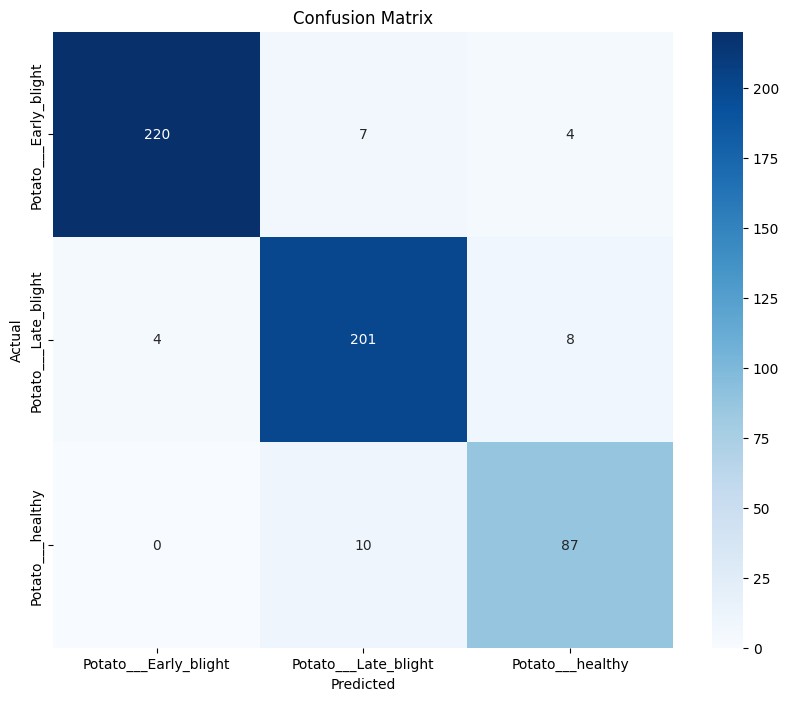

In [7]:
# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

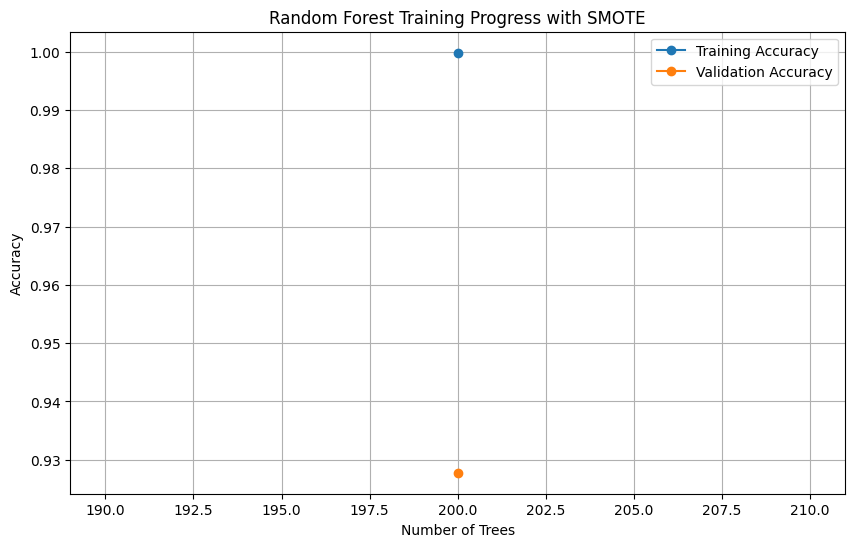

In [8]:
# Plot accuracy progression
plt.figure(figsize=(10, 6))
plt.plot(tree_counts, train_accuracies, label='Training Accuracy', marker='o')
plt.plot(tree_counts, val_accuracies, label='Validation Accuracy', marker='o')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Random Forest Training Progress with SMOTE')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_curve.png', bbox_inches='tight')
plt.show()

In [9]:
# Save model and features
joblib.dump(rf, 'random_forest_smote_model.pkl')
np.savez('extracted_features.npz', 
         X_train=X_train_features,
         X_val=X_val_features,
         X_test=X_test_features,
         y_train=y_train,
         y_val=y_val,
         y_test=y_test)

print("\nModel saved as 'random_forest_smote_model.pkl'")
print("Features saved as 'extracted_features.npz'")


Model saved as 'random_forest_smote_model.pkl'
Features saved as 'extracted_features.npz'


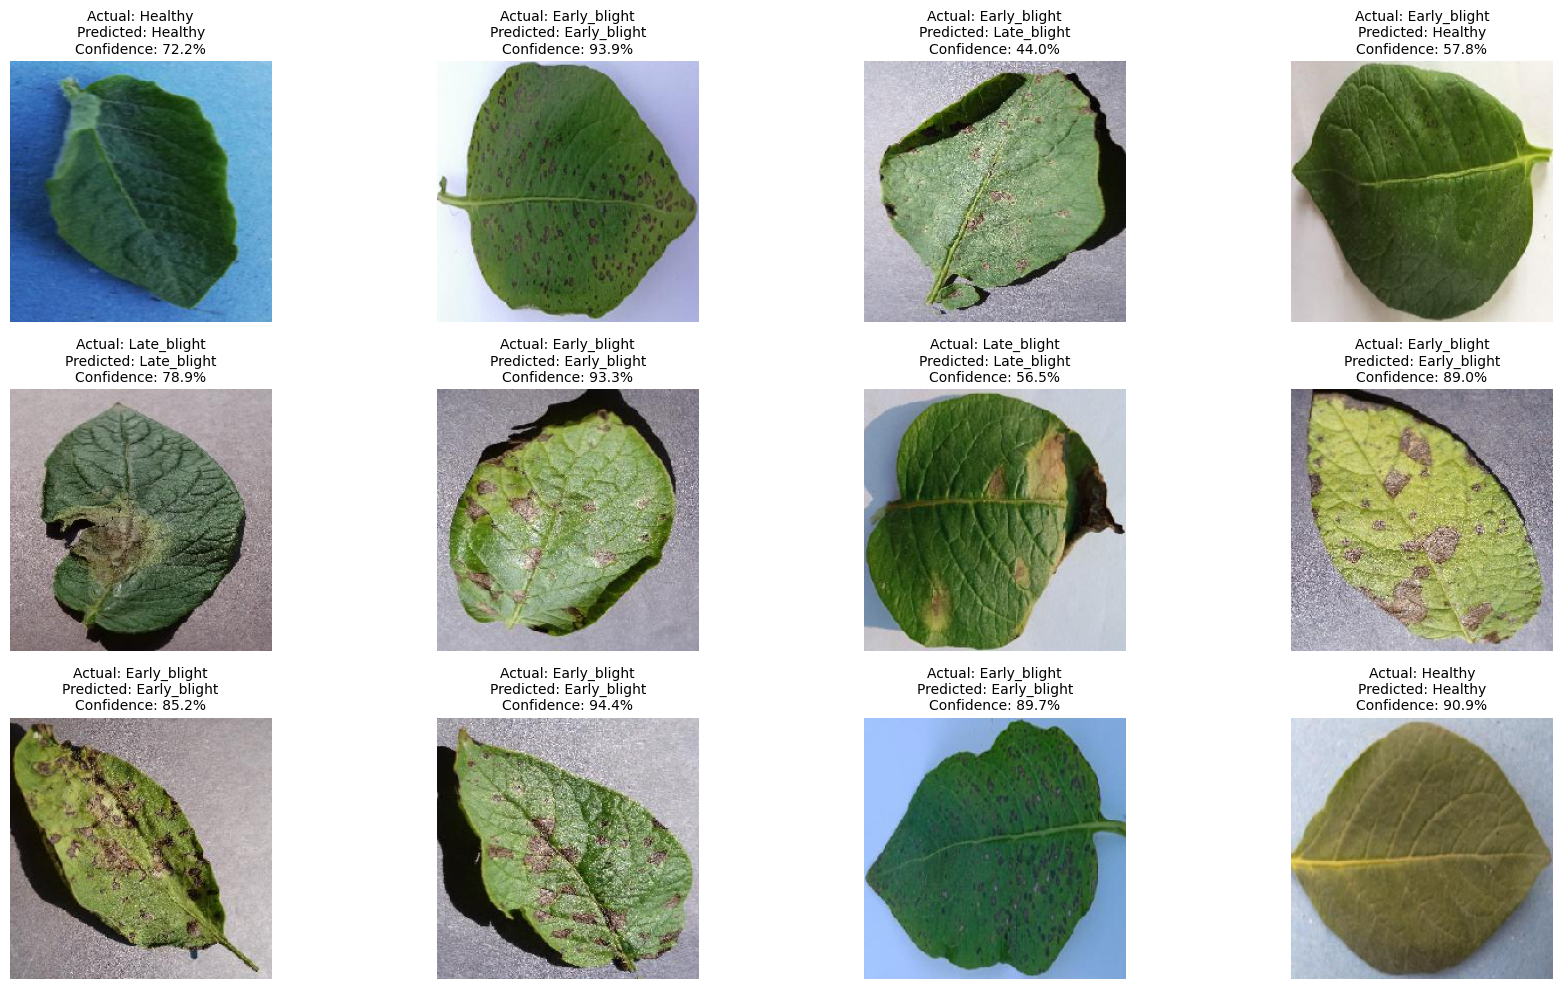

In [10]:
import random
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Map class indices to class names
class_names = ['Early_blight', 'Late_blight', 'Healthy']

# Select 12 random test images
random_indices = random.sample(range(len(X_test_paths)), 12)
selected_paths = [X_test_paths[i] for i in random_indices]
selected_labels = [y_test[i] for i in random_indices]

# Prepare figure
plt.figure(figsize=(18, 10))

# Predict and display
for i, (img_path, true_label) in enumerate(zip(selected_paths, selected_labels)):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_preprocessed = preprocess_input(img_array)
    features = feature_extractor.predict(np.expand_dims(img_preprocessed, axis=0), verbose=0)
    
    # Predict with Random Forest
    prediction = rf.predict(features)[0]
    proba = rf.predict_proba(features)[0]
    confidence = np.max(proba) * 100

    # Plot image with prediction info
    plt.subplot(3, 4, i + 1)
    plt.imshow(np.array(img))  # <-- FIXED LINE
    plt.axis('off')
    plt.title(
        f"Actual: {class_names[true_label]}\nPredicted: {class_names[prediction]}\nConfidence: {confidence:.1f}%",
        fontsize=10
    )

plt.tight_layout()
plt.show()
